# Phase 1: Problem Definition

## Background
Campus placement depends on multiple academic and skill-based factors.
This project aims to analyze which factors significantly influence placement.

## Research Questions
1. Does CGPA affect placement?
2. Do internships impact placement?
3. Which skills are most important?
4. Can we predict placement using machine learning?

## Hypothesis
H₀: CGPA does not affect placement.
H₁: CGPA significantly affects placement.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

train = pd.read_csv("train.csv")
train.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


In [22]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            45000 non-null  int64  
 1   Age                   45000 non-null  int64  
 2   Gender                45000 non-null  object 
 3   Degree                45000 non-null  object 
 4   Branch                45000 non-null  object 
 5   CGPA                  45000 non-null  float64
 6   Internships           45000 non-null  int64  
 7   Projects              45000 non-null  int64  
 8   Coding_Skills         45000 non-null  int64  
 9   Communication_Skills  45000 non-null  int64  
 10  Aptitude_Test_Score   45000 non-null  int64  
 11  Soft_Skills_Rating    45000 non-null  int64  
 12  Certifications        45000 non-null  int64  
 13  Backlogs              45000 non-null  int64  
 14  Placement_Status      45000 non-null  object 
dtypes: float64(1), int6

,Student_ID,Age,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,24977.962600,20.999333,7.002290,0.774089,3.734222,5.691800,5.501644,69.385356,5.501644,1.800956,0.888133
std,14425.605704,1.995071,0.993855,0.844750,0.923738,1.994674,1.515374,13.909710,1.238722,0.650104,0.970954
min,1.000000,18.000000,4.500000,0.000000,1.000000,1.000000,1.000000,35.000000,1.000000,0.000000,0.000000
25%,12509.750000,19.000000,6.320000,0.000000,3.000000,4.000000,4.000000,60.000000,5.000000,1.000000,0.000000
50%,24957.500000,21.000000,7.000000,1.000000,4.000000,6.000000,6.000000,69.000000,5.000000,2.000000,1.000000
75%,37475.250000,23.000000,7.670000,1.000000,4.000000,7.000000,7.000000,79.000000,6.000000,2.000000,2.000000
max,50000.000000,24.000000,9.800000,3.000000,6.000000,10.000000,10.000000,100.000000,10.000000,3.000000,3.000000


In [23]:
train.isnull().sum()

Student_ID              0
Age                     0
Gender                  0
Degree                  0
Branch                  0
CGPA                    0
Internships             0
Projects                0
Coding_Skills           0
Communication_Skills    0
Aptitude_Test_Score     0
Soft_Skills_Rating      0
Certifications          0
Backlogs                0
Placement_Status        0
dtype: int64

In [24]:
train.duplicated().sum()

np.int64(0)

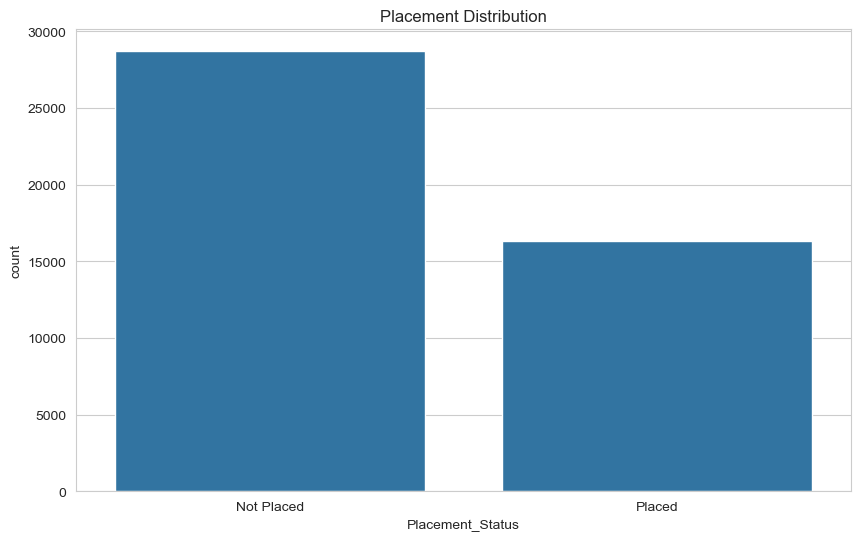

In [25]:
sns.countplot(x='Placement_Status', data=train)
plt.title("Placement Distribution")
plt.show()

In [26]:
print("Mean CGPA:", train['CGPA'].mean())
print("Median CGPA:", train['CGPA'].median())
print("Standard Deviation:", train['CGPA'].std())

Mean CGPA: 7.002290222222222
Median CGPA: 7.0
Standard Deviation: 0.9938551953305415


In [27]:
train['Branch'].value_counts()

Branch
ME       9056
ECE      9026
CSE      8989
Civil    8981
IT       8948
Name: count, dtype: int64

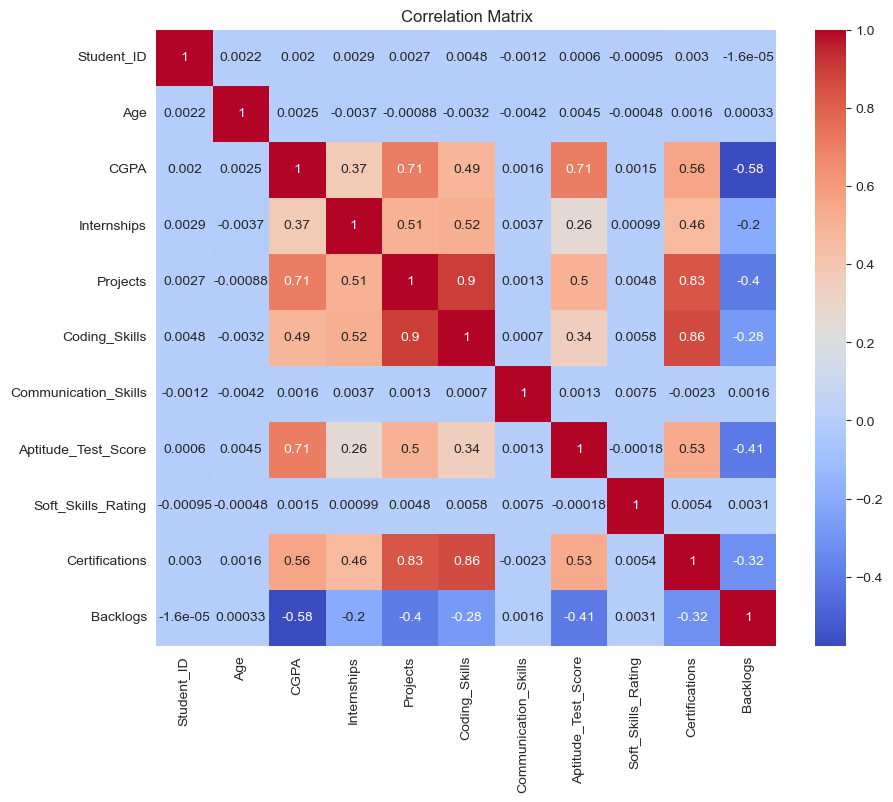

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [29]:
placed = train[train['Placement_Status'] == 'Placed']
not_placed = train[train['Placement_Status'] == 'Not Placed']

print("Average CGPA (Placed):", placed['CGPA'].mean())
print("Average CGPA (Not Placed):", not_placed['CGPA'].mean())

Average CGPA (Placed): 7.650108509073076
Average CGPA (Not Placed): 6.633940672058003


In [30]:
t_stat, p_value = stats.ttest_ind(
    placed['CGPA'],
    not_placed['CGPA']
)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 119.72438637718058
P-Value: 0.0


In [31]:
mean = train['CGPA'].mean()
se = train['CGPA'].std() / np.sqrt(len(train))

ci = stats.t.interval(0.95, len(train)-1, loc=mean, scale=se)

print("95% Confidence Interval:", ci)

95% Confidence Interval: (np.float64(6.993107390452558), np.float64(7.011473053991887))


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

train['Placement_Status'] = train['Placement_Status'].map({
    'Placed':1,
    'Not Placed':0
})

features = ['CGPA', 'Internships', 'Projects',
            'Coding_Skills', 'Communication_Skills',
            'Aptitude_Test_Score', 'Soft_Skills_Rating',
            'Certifications', 'Backlogs']

X = train[features]
y = train['Placement_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))

Model Accuracy: 0.8642222222222222

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.90      0.89      5709
           1       0.82      0.80      0.81      3291

    accuracy                           0.86      9000
   macro avg       0.85      0.85      0.85      9000
weighted avg       0.86      0.86      0.86      9000



# Phase 7: Reporting & Presentation

## Executive Summary

This project analyzed the Student Placement dataset using descriptive and inferential statistical methods. The goal was to identify key factors influencing placement status and build a predictive model.

## Key Findings

- Students with higher CGPA have significantly better placement chances.
- Internship experience positively influences placement probability.
- Coding skills and aptitude test scores strongly impact placement.
- Backlogs negatively affect placement outcomes.
- The Logistic Regression model achieved an accuracy of ___%.

## Conclusion

The statistical analysis confirms that academic performance and skill development are major determinants of student placement. Students should focus on improving CGPA, gaining internships, and strengthening technical and communication skills to increase employability.

## Limitations

- Dataset size may limit generalization.
- Only numerical predictors were used for modeling.
- External factors such as market conditions were not considered.

## Future Improvements

- Try advanced models (Random Forest, XGBoost).
- Add feature importance analysis.
- Build a deployment-ready prediction system using Streamlit.